In [4]:
from itertools import product
import pandas as pd
import numpy as np
from typing import List, Dict, Optional
import random

TOTAL_MODULES = 16
MODULE_TIME = 2

J = list(range(1, 6))       # Jobs 1–5
K = ['G', 'D', 'B']
O_set = set(range(1, 21))
R = [1, 2, 3, 4, 5]
M = [1, 2, 3, 4, 5]
H = 100000

GRADE_MODULE_RANGES = {
    'A': (12, 15),
    'B': (6, 11),
    'C': (0, 5),
}

ROUTE_VALUE_BY_GRADE = {
    'A': {
        1: 200,   # full restoration
        2: 100,   # BMC rebalance
        3: 0,     # no action / discard
        4: 200,   # full restoration
        5: 75    # bypass damaged cell
    },
    'B': {
        1: 200,
        2: 70,
        3: 0,
        4: 200,
        5: 35
    },
    'C': {
        1: 200,
        2: 40,
        3: 0,
        4: 200,
        5: 20
    }
}


M_o = {
    1: [1, 2],  2: [3],     3: [1, 2],  4: [1, 2],
    5: [1, 2],  6: [1, 2],  7: [5],     8: [4],
    9: [1, 2],  10: [5],    11: [1, 2], 12: [1, 2],
    13: [3],    14: [1, 2], 15: [4],    16: [3],
    17: [4],    18: [3, 5], 19: [1, 2], 20: [1, 2]
}


route_ops = {
    1: [1, 2, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17],
    2: [1, 2, 4, 5, 8, 12, 13, 15, 16, 17],
    3: [1, 2, 3, 4, 5, 6, 7, 8],
    4: [9, 10, 11, 12, 13, 14, 15, 16, 17],
    5: [1, 2, 3, 14, 15, 16, 17],
}

BASE_OP_TIMES = {
    1: 3, 2: 5, 3: 12, 4: 4, 5: 11,
    6: 19, 8: 20, 9: 17, 11: 16,
    12: 18, 13: 4, 14: 11, 15: 8,
    16: 9, 17: 15, 18: 6, 19: 23, 20: 12
}

def generate_battery_data(
    grades: List[str],
    routes: Optional[List[int]] = None
) -> Dict:

    num_jobs = len(grades)
    jobs = list(range(1, num_jobs + 1))

    GOOD_MODULES = {}
    for j, g in zip(jobs, grades):
        low, high = GRADE_MODULE_RANGES[g]
#         GOOD_MODULES[j] = random.randint(low, high)
        GOOD_MODULES[j] = high
    DEGRADED_MODULES = {j: TOTAL_MODULES - GOOD_MODULES[j] for j in jobs}

    # Job–route mapping
    R_j = {j: R for j in jobs}
    O_j = {j: list(O_set) for j in jobs}
    delta_or = {(o, r): int(o in route_ops[r]) for r in R for o in O_set}

    # Processing times
    p_jorm = {}
    for j, o, r, m in product(jobs, O_set, R, M):
        if m not in M_o.get(o, []):
            continue

        if o == 7:  # Remove modules
            p_jorm[(j, o, r, m)] = (
                MODULE_TIME * DEGRADED_MODULES[j] if r == 1 else
                MODULE_TIME * TOTAL_MODULES if r == 3 else 0
            )
        elif o == 10:  # Place modules
            p_jorm[(j, o, r, m)] = (
                MODULE_TIME * DEGRADED_MODULES[j] if r == 1 else
                MODULE_TIME * TOTAL_MODULES if r == 4 else 0
            )
        else:
            p_jorm[(j, o, r, m)] = BASE_OP_TIMES.get(o, 0)

    # Material demand
    a_jrk = {}
    for j in jobs:
        a_jrk[(j, 1, 'G')] = DEGRADED_MODULES[j]  # repair
        a_jrk[(j, 2, 'B')] = 0                    # BMC replace
        a_jrk[(j, 4, 'G')] = TOTAL_MODULES        # reassembly
        a_jrk[(j, 4, 'B')] = 1
        a_jrk[(j, 5, 'B')] = 0                    # energy storage

    # Supply
    b_underline_jrk = {(j, 3, 'G'): GOOD_MODULES[j] for j in jobs}
    b_underline_jrk.update({(j, 3, 'D'): DEGRADED_MODULES[j] for j in jobs})
    b_underline_jrk.update({(j, 3, 'B'): 1 for j in jobs})

    # Capacity
    U_jk = {(j, 'G'): GOOD_MODULES[j] for j in jobs}
    U_jk.update({(j, 'D'): DEGRADED_MODULES[j] for j in jobs})
    U_jk.update({(j, 'B'): 1 for j in jobs})

    # Fixed routes
    if routes is not None:
        fixed_route_j = {j: routes[i] for i, j in enumerate(jobs)}
    else:
        fixed_route_j = {j: random.choice(R) if random.random() < 0.4 else 3 for j in jobs}

    # Construct data dictionary
    data = {
        'J': jobs,
        'O_j': O_j,
        'R_j': R_j,
        'M_o': M_o,
        'K': K,
        'p_jorm': p_jorm,
        'delta_or': delta_or,
        'a_jrk': a_jrk,
        'b_underline_jrk': b_underline_jrk,
        'U_jk': U_jk,
        'H': H,
        'route_ops': route_ops,
        'fixed_route_j': fixed_route_j,
        'GOOD_MODULES': GOOD_MODULES,
        'DEGRADED_MODULES': DEGRADED_MODULES,
        'BASE_OP_TIMES': BASE_OP_TIMES
    }

    return data


In [5]:
import random
import math
from collections import defaultdict
from typing import Dict, List, Tuple

def fifo_machine_choice(m_list, machine_available):
    best_m = None
    best_t = math.inf
    for m in sorted(m_list):
        t = machine_available.get(m, 0.0)
        if t < best_t:
            best_t = t
            best_m = m
    return best_m

def schedule_job_operations(job, route, data,
                            machine_available, job_last_completion,
                            s_o_j, c_o_j, x_o_j_m, op_enqueue_order):

    p_jorm = data['p_jorm']
    route_ops = data['route_ops']
    M_o = data['M_o']
    BASE_OP_TIMES = data['BASE_OP_TIMES']

    prev_completion = 0.0

    for o in route_ops.get(route, []):
        machines = M_o.get(o, [])
        if not machines:
            continue

        m = fifo_machine_choice(machines, machine_available)

        # if no the machine is not compatible, set the time to be zero
        if (job, o, route, m) in p_jorm:
            p = p_jorm[(job, o, route, m)]
        else:
            p = BASE_OP_TIMES.get(o, 0.0)

        start = max(prev_completion, machine_available[m])
        comp = start + p

        s_o_j[(o, job)] = start
        c_o_j[(o, job)] = comp
        x_o_j_m[(o, job, m)] = 1

        machine_available[m] = comp
        job_last_completion[job] = comp
        prev_completion = comp

        op_enqueue_order.append((job, o))

def recompute_machine_availability_from_assignments(x_o_j_m, c_o_j, machine_available):
    new_avail = defaultdict(float)
    for (o, j, m), v in x_o_j_m.items():
        if v:
            new_avail[m] = max(new_avail[m], c_o_j[(o, j)])
    for m, t in machine_available.items():
        new_avail[m] = max(new_avail[m], t)
    return new_avail

def run_grade_based_heuristic(grades, seed=0):

#     random.seed(seed)
    data = generate_battery_data(grades)

    J = data['J']
    GOOD_MODULES = data['GOOD_MODULES']
    route_ops = data['route_ops']

    # Partition jobs
    J_A = [j for j, g in zip(J, grades) if g == 'A']
    J_B = [j for j, g in zip(J, grades) if g == 'B']
    J_C = [j for j, g in zip(J, grades) if g == 'C']
    # Initialize the set of the grade B batteries for the disassembly
    J_B3 = set()

    # Initialize the set for outputs
    route_assignments = {}
    s_o_j, c_o_j, x_o_j_m = {}, {}, {}
    op_enqueue_order = []
    machine_available = defaultdict(float)
    job_last_completion = defaultdict(float)

    Z = 0
    N_m = TOTAL_MODULES
    z_j = {j: GOOD_MODULES[j] for j in J}

    for j in J_C:
        route_assignments[j] = 3
        schedule_job_operations(j, 3, data,
                                machine_available, job_last_completion,
                                s_o_j, c_o_j, x_o_j_m, op_enqueue_order)
        Z += z_j[j]

    C_C_max = max((job_last_completion[j] for j in J_C), default=0.0)

    for j in J_A:
        b_j = z_j[j]

        while True:
            if Z >= N_m - b_j:
                route_assignments[j] = 1
                schedule_job_operations(j, 1, data,
                                        machine_available, job_last_completion,
                                        s_o_j, c_o_j, x_o_j_m, op_enqueue_order)
                Z -= N_m - b_j
                break

            remaining_B = [jb for jb in J_B if jb not in J_B3]

            if not remaining_B:
                # fallback: route 2
                route_assignments[j] = 2
                schedule_job_operations(j, 2, data,
                                        machine_available, job_last_completion,
                                        s_o_j, c_o_j, x_o_j_m, op_enqueue_order)

                first_op = route_ops[2][0]
                if s_o_j[(first_op, j)] < C_C_max:
                    shift = C_C_max - s_o_j[(first_op, j)]
                    for (o, jj) in list(s_o_j.keys()):
                        if jj == j:
                            s_o_j[(o, jj)] += shift
                            c_o_j[(o, jj)] += shift
                    job_last_completion[j] += shift
                    machine_available = recompute_machine_availability_from_assignments(
                        x_o_j_m, c_o_j, machine_available)
                break

            # replenish inventory using B job
            jb = random.choice(remaining_B)
            J_B3.add(jb)
            route_assignments[jb] = 3

            schedule_job_operations(jb, 3, data,
                                    machine_available, job_last_completion,
                                    s_o_j, c_o_j, x_o_j_m, op_enqueue_order)

            first_op = route_ops[3][0]
            if s_o_j[(first_op, jb)] < C_C_max:
                shift = C_C_max - s_o_j[(first_op, jb)]
                for (o, jj) in list(s_o_j.keys()):
                    if jj == jb:
                        s_o_j[(o, jj)] += shift
                        c_o_j[(o, jj)] += shift
                job_last_completion[jb] += shift
                machine_available = recompute_machine_availability_from_assignments(
                    x_o_j_m, c_o_j, machine_available)

            Z += z_j[jb]

    C_A_max = max((job_last_completion[j] for j in J_A), default=0.0)

    for j in J_B:
        if j in J_B3:
            continue

        b_j = z_j[j]

        if Z >= N_m - b_j:
            r = 1
            Z -= N_m - b_j
        elif Z >= N_m / 4:
            r = 2
        else:
            r = 5

        route_assignments[j] = r
        schedule_job_operations(j, r, data,
                                machine_available, job_last_completion,
                                s_o_j, c_o_j, x_o_j_m, op_enqueue_order)

        first_op = route_ops[r][0]
        if s_o_j[(first_op, j)] < C_A_max:
            shift = C_A_max - s_o_j[(first_op, j)]
            for (o, jj) in list(s_o_j.keys()):
                if jj == j:
                    s_o_j[(o, jj)] += shift
                    c_o_j[(o, jj)] += shift
            job_last_completion[j] += shift
            machine_available = recompute_machine_availability_from_assignments(
                x_o_j_m, c_o_j, machine_available)
            
    C_max = max(c_o_j.values()) if c_o_j else 0.0

    V = sum(
        ROUTE_VALUE_BY_GRADE[grades[j - 1]].get(r, 0)
        for j, r in route_assignments.items()
        if j <= len(grades)
    )

    return {
        'route_assignments': route_assignments,
        'Z_final': Z,
        'C_max': C_max,
        'V': V,
        'J_B3': list(J_B3),

        # ---- required for visualization ----
        's_o_j': s_o_j,
        'c_o_j': c_o_j,
        'x_o_j_m': x_o_j_m
    }

grades = ['A', 'A', 'B', 'B', 'B', 'B', 'C']
res = run_grade_based_heuristic(grades, seed=42)

print("Route assignments:")
for j, r in sorted(res['route_assignments'].items()):
    print(f"Job {j} → Route {r}")

print("\nFinal Z:", res['Z_final'])
print("J_B3:", res['J_B3'])
print("C_max:", res['C_max'])
print("V:", res['V'])


Route assignments:
Job 1 → Route 1
Job 2 → Route 1
Job 3 → Route 5
Job 4 → Route 5
Job 5 → Route 5
Job 6 → Route 5
Job 7 → Route 3

Final Z: 3
J_B3: []
C_max: 548.0
V: 540


In [6]:
# ============================================================
# Example execution
# ============================================================

grades = ['A', 'A', 'B', 'B', 'B', 'B', 'C']


grade_sets = [
    ['A', 'B', 'B', 'B', 'C'],
    ['A', 'B', 'B', 'C', 'C'],
    ['A', 'A', 'B', 'B', 'C'],
    ['A', 'B', 'B', 'B', 'B', 'C'],
    ['A', 'B', 'B', 'B', 'C', 'C'],
    ['A', 'A', 'B', 'B', 'B', 'C'],
    ['A', 'A', 'B', 'B', 'C', 'C'],
    ['A', 'B', 'B', 'B', 'B', 'B', 'C'],
    ['A', 'B', 'B', 'B', 'B', 'C', 'C'],
    ['A', 'A', 'B', 'B', 'B', 'B', 'C'],
    ['A', 'A', 'B', 'B', 'B', 'C', 'C'],
    ['A', 'A', 'A', 'B', 'B', 'B', 'C'],
    ['A', 'B', 'B', 'B', 'C', 'C', 'C'],
]


# Initialize storage
heuristic_results = []

# Iterate through each grade set
for idx, grades in enumerate(grade_sets):
    # Run the heuristic function with a fixed seed
    res = run_grade_based_heuristic(grades, seed=42)
    
    # Store results in a dictionary
    result_dict = {
        'scenario': f'scenario_{idx+1}',
        'grades': grades,
        'route_assignments': res['route_assignments'],
        'Z_final': res['Z_final'],
        'J_B3': res['J_B3'],
        'C_max': res['C_max'],
        'V': res['V']
    }
    
    heuristic_results.append(result_dict)

# Convert to DataFrame
df_heuristic_results = pd.DataFrame(heuristic_results)

# Display the DataFrame
print(df_heuristic_results)

# Count number of Route 3 (disassembly) jobs
df_heuristic_results['num_route_3'] = df_heuristic_results['route_assignments'].apply(
    lambda ra: sum(1 for r in ra.values() if r == 3)
)

# Display relevant columns
print(
    df_heuristic_results[
        ['scenario', 'grades', 'num_route_3', 'V', 'C_max']
    ]
)

       scenario                 grades  \
0    scenario_1        [A, B, B, B, C]   
1    scenario_2        [A, B, B, C, C]   
2    scenario_3        [A, A, B, B, C]   
3    scenario_4     [A, B, B, B, B, C]   
4    scenario_5     [A, B, B, B, C, C]   
5    scenario_6     [A, A, B, B, B, C]   
6    scenario_7     [A, A, B, B, C, C]   
7    scenario_8  [A, B, B, B, B, B, C]   
8    scenario_9  [A, B, B, B, B, C, C]   
9   scenario_10  [A, A, B, B, B, B, C]   
10  scenario_11  [A, A, B, B, B, C, C]   
11  scenario_12  [A, A, A, B, B, B, C]   
12  scenario_13  [A, B, B, B, C, C, C]   

                             route_assignments  Z_final J_B3  C_max    V  
0               {5: 3, 1: 1, 2: 2, 3: 2, 4: 2}        4   []  492.0  410  
1               {4: 3, 5: 3, 1: 1, 2: 1, 3: 2}        4   []  498.0  470  
2               {5: 3, 1: 1, 2: 1, 3: 5, 4: 5}        3   []  458.0  470  
3         {6: 3, 1: 1, 2: 2, 3: 2, 4: 2, 5: 2}        4   []  571.0  480  
4         {5: 3, 6: 3, 1: 1, 2: 1, 3

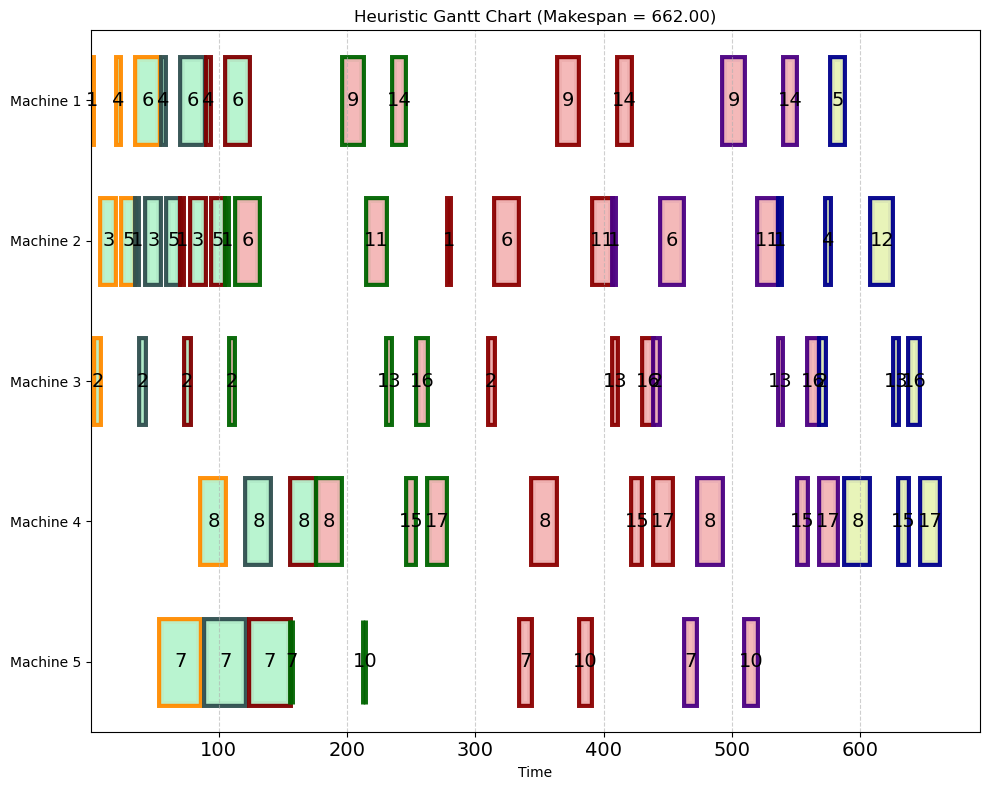

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.patheffects as pe

def lighten_color(color, amount=0.55):
    r, g, b, *_ = mcolors.to_rgba(color)
    return (
        r + (1 - r) * amount,
        g + (1 - g) * amount,
        b + (1 - b) * amount,
        1.0
    )

def generate_distinct_route_colors(routes, lightening=0.7):
    """
    Generate distinct colors for routes using HSV space.
    """
    n = len(routes)
    hues = np.linspace(0, 1, n, endpoint=False)
    base_colors = {r: mcolors.hsv_to_rgb((h, 0.9, 0.85)) for r, h in zip(routes, hues)}
    return {r: lighten_color(base_colors[r], amount=lightening) for r in routes}

def visualize_heuristic_gantt(result):
    """
    Visualize the Gantt chart for heuristic solution with 5 fixed machine rows.
    """
    s_o_j = result['s_o_j']
    c_o_j = result['c_o_j']
    x_o_j_m = result['x_o_j_m']
    route_assignments = result['route_assignments']

    gantt_data = []
    for (o, j, m), assigned in x_o_j_m.items():
        if assigned:
            gantt_data.append({
                'Job': f'Job {j}',
                'Route': f'Route {route_assignments[j]}',
                'Operation': f'Op {o}',
                'Machine': f'Machine {m}',
                'Start': s_o_j[(o, j)],
                'End': c_o_j[(o, j)],
                'Duration': c_o_j[(o, j)] - s_o_j[(o, j)]
            })

    df = pd.DataFrame(gantt_data)
    
    # Always include 5 machines and 5 routes for legend and axis consistency
    all_machines = [f'Machine {i}' for i in range(1, 6)]
    machine_y_map = {m: i for i, m in enumerate(all_machines)}
    
    all_routes = [f'Route {i}' for i in range(1, 6)]
    route_colors = generate_distinct_route_colors(all_routes, lightening=0.7)

    # Job edge colors
    if not df.empty:
        jobs = sorted(df['Job'].unique(), key=lambda x: int(x.split()[1]))
        df = df.sort_values(by=['Machine', 'Start'])
    else:
        jobs = []
        
    # JOB → edge color (use all dark colors)
    jobs = sorted(df['Job'].unique(), key=lambda x: int(x.split()[1]))
    dark_colors = [
    '#006400',  # dark green
    '#8B0000',  # dark red
    '#4B0082',  # dark indigo / purple
    '#00008B',  # dark blue
    '#FF8C00',  # dark orange
    '#2F4F4F',  # dark slate gray
    '#800000',  # maroon
    '#008B8B',  # dark cyan
    '#556B2F',  # dark olive green
    '#8B008B'   # dark magenta
]
    job_edge_colors = {j: dark_colors[i % len(dark_colors)] for i, j in enumerate(jobs)}

    fig, ax = plt.subplots(figsize=(10, 8)) # Fixed size for comparison
    
    if not df.empty:
        for _, row in df.iterrows():
            if row['Machine'] in machine_y_map:
                y = machine_y_map[row['Machine']]
                op_number = row['Operation'].split()[1]  # Only operation number

                bar = ax.barh(
                    y=y,
                    width=row['Duration']-2,
                    left=row['Start']+0.5,
                    height=0.6,
                    color=route_colors[row['Route']],
                    edgecolor=job_edge_colors[row['Job']],
                    linewidth=1.0,
                    alpha=0.95
                )

                # Make edge grow inward
                for rect in bar:
                    rect.set_path_effects([pe.Stroke(linewidth=5.0, foreground=job_edge_colors[row['Job']], capstyle='butt', joinstyle='miter'), pe.Normal()])

                ax.text(
                    row['Start'] + row['Duration'] / 2,
                    y,
                    op_number,
                    ha='center',
                    va='center',
                    fontsize=14,
                    color='black'
                )

    ax.set_yticks(range(len(all_machines)))
    ax.set_yticklabels(all_machines)
    ax.set_ylim(-0.5, len(all_machines) - 0.5) # Force 5 rows spacing
    
    ax.set_xlabel("Time")
    ax.tick_params(axis='x', labelsize=14)
    ax.set_title(f"Heuristic Gantt Chart (Makespan = {result['C_max']:.2f})")
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

visualize_heuristic_gantt(res)